In [39]:
import tensorflow
from tensorflow.keras.models import Sequential
from keras.layers import Dense, Embedding, SimpleRNN, Dropout, LSTM, GRU, Bidirectional, GlobalAveragePooling1D
from keras.datasets import imdb
from keras.preprocessing.sequence import pad_sequences

In [2]:
(X_train, y_train), (X_test, y_test)=imdb.load_data(num_words=10000)

X_train=pad_sequences(X_train, maxlen=100, padding='pre')
X_test=pad_sequences(X_test, maxlen=100, padding='pre')

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
model=Sequential()

model.add(Embedding(10000, 32))
model.add(SimpleRNN(5, return_sequences=True))
model.add(Dropout(0.5))
model.add(SimpleRNN(5))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))
model.build(input_shape=(None, X_train.shape[1]))

In [9]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 100, 5)         │           190 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 5)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320,251 (1.22 MB)

 Trainable params: 320,251 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [11]:
history=model.fit(X_train, y_train, epochs=15, validation_data=(X_test, y_test))

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 32ms/step - accuracy: 0.7584 - loss: 0.5294 - val_accuracy: 0.8003 - val_loss: 0.4469
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 21ms/step - accuracy: 0.8342 - loss: 0.4218 - val_accuracy: 0.8136 - val_loss: 0.4360
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.8651 - loss: 0.3640 - val_accuracy: 0.8161 - val_loss: 0.4413
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.8798 - loss: 0.3286 - val_accuracy: 0.8023 - val_loss: 0.4747
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.8924 - loss: 0.2982 - val_accuracy: 0.8179 - val_loss: 0.4762
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.9079 - loss: 0.2629 - val_accuracy: 0.8134 - val_loss: 0.4795
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.9093 - loss: 0.2599 - val_accuracy: 0.8214 - val_loss: 0.4908
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.9281 - loss: 0.2181 - 

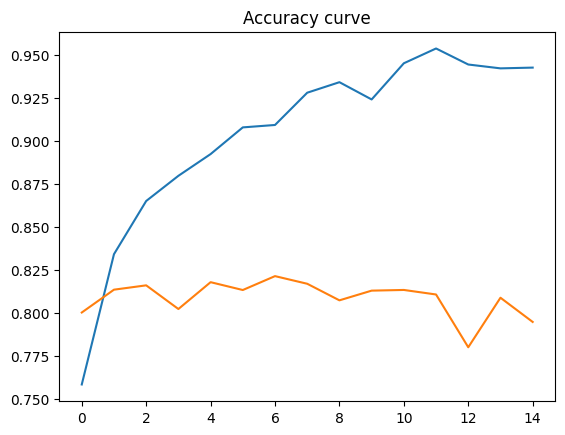

In [12]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title("Accuracy curve")
plt.show()

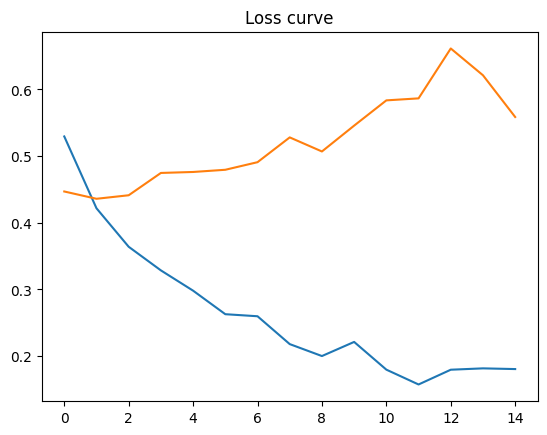

In [13]:
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title("Loss curve")
plt.show()

# LSTM

In [15]:
model2=Sequential()

model2.add(Embedding(10000, 32))
model2.add(LSTM(5, return_sequences=True))
model2.add(Dropout(0.5))
model2.add(LSTM(5))
model2.add(Dropout(0.2))
model2.add(Dense(1, activation='sigmoid'))
model2.build(input_shape=(None, X_train.shape[1]))

In [16]:
model2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 100, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100, 5)         │           760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100, 5)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 5)              │           220 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320,986 (1.22 MB)

 Trainable params: 320,986 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model2.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [18]:
history2=model2.fit(X_train, y_train, epochs=15, validation_data=(X_test, y_test))

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 19ms/step - accuracy: 0.7456 - loss: 0.5166 - val_accuracy: 0.8378 - val_loss: 0.3844
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 20ms/step - accuracy: 0.8771 - loss: 0.3245 - val_accuracy: 0.8495 - val_loss: 0.3471
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 21ms/step - accuracy: 0.9141 - loss: 0.2428 - val_accuracy: 0.8522 - val_loss: 0.3615
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.9386 - loss: 0.1890 - val_accuracy: 0.8442 - val_loss: 0.4061
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.9544 - loss: 0.1476 - val_accuracy: 0.8444 - val_loss: 0.4477
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.9677 - loss: 0.1131 - val_accuracy: 0.8339 - val_loss: 0.5601
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.9734 - loss: 0.0996 - val_accuracy: 0.8338 - val_loss: 0.5977
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.9787 - loss: 0.0817 - 

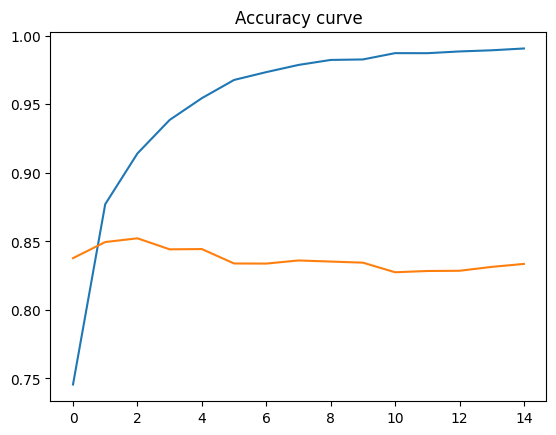

In [19]:
plt.plot(history2.history['accuracy'], label='Train')
plt.plot(history2.history['val_accuracy'], label='Val')
plt.title("Accuracy curve")
plt.show()

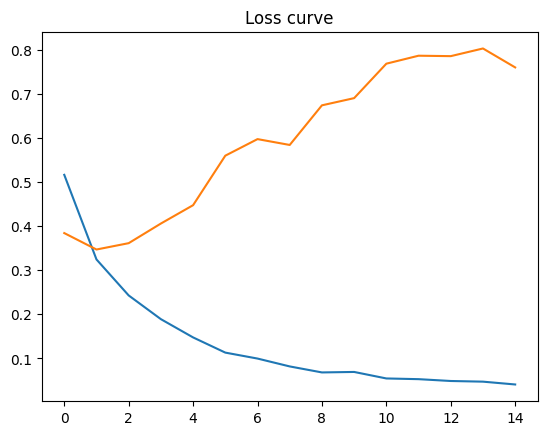

In [20]:
plt.plot(history2.history['loss'], label='Train')
plt.plot(history2.history['val_loss'], label='Val')
plt.title("Loss curve")
plt.show()

# GRU

In [21]:
model3=Sequential()

model3.add(Embedding(10000, 32))
model3.add(GRU(5, return_sequences=True))
model3.add(Dropout(0.5))
model3.add(GRU(5))
model3.add(Dropout(0.2))
model3.add(Dense(1, activation='sigmoid'))
model3.build(input_shape=(None, X_train.shape[1]))

In [22]:
model3.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 100, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 100, 5)         │           585 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 100, 5)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 5)              │           180 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320,771 (1.22 MB)

 Trainable params: 320,771 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model3.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [24]:
history3=model3.fit(X_train, y_train, epochs=15, validation_data=(X_test, y_test))

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - accuracy: 0.7194 - loss: 0.5488 - val_accuracy: 0.8228 - val_loss: 0.4050
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.8590 - loss: 0.3498 - val_accuracy: 0.8375 - val_loss: 0.3725
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.8958 - loss: 0.2740 - val_accuracy: 0.8486 - val_loss: 0.3581
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.9182 - loss: 0.2282 - val_accuracy: 0.8450 - val_loss: 0.3854
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.9345 - loss: 0.1909 - val_accuracy: 0.8393 - val_loss: 0.4145
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.9488 - loss: 0.1560 - val_accuracy: 0.8317 - val_loss: 0.4857
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.9570 - loss: 0.1340 - val_accuracy: 0.8298 - val_loss: 0.5220
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.9670 - loss: 0.1086 - 

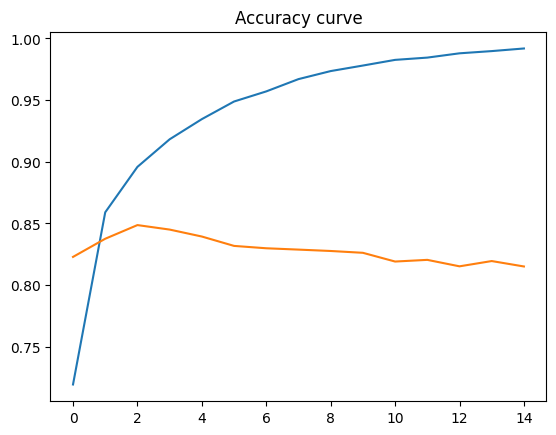

In [25]:
plt.plot(history3.history['accuracy'], label='Train')
plt.plot(history3.history['val_accuracy'], label='Val')
plt.title("Accuracy curve")
plt.show()

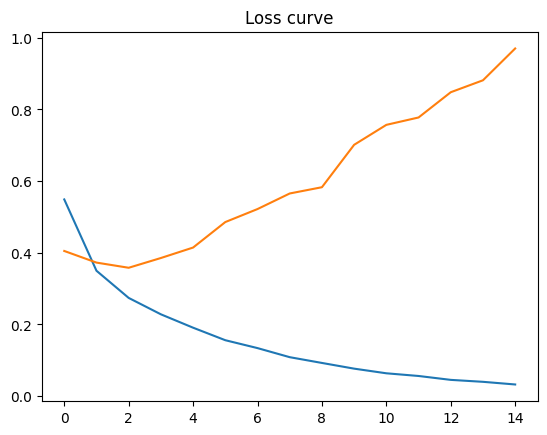

In [26]:
plt.plot(history3.history['loss'], label='Train')
plt.plot(history3.history['val_loss'], label='Val')
plt.title("Loss curve")
plt.show()

# Bidirectional RNNs

In [41]:
model4=Sequential()

model4.add(Embedding(10000, 32))
model4.add(Bidirectional(LSTM(5)))
model4.add(Dropout(0.5))
model4.add(Dense(1, activation='sigmoid'))
model4.build(input_shape=(None, X_train.shape[1]))

In [42]:
model4.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_11 (Embedding)        │ (None, 100, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ (None, 10)             │         1,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321,531 (1.23 MB)

 Trainable params: 321,531 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

In [43]:
model4.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [44]:
import time
start=time.time()
history4=model4.fit(X_train, y_train, epochs=15, validation_data=(X_test, y_test))
print('Time :', time.time()-start)

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - accuracy: 0.7431 - loss: 0.5270 - val_accuracy: 0.8111 - val_loss: 0.4262
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.8647 - loss: 0.3527 - val_accuracy: 0.8424 - val_loss: 0.3541
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.8929 - loss: 0.2883 - val_accuracy: 0.8462 - val_loss: 0.3693
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.9141 - loss: 0.2445 - val_accuracy: 0.8414 - val_loss: 0.3940
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.9261 - loss: 0.2095 - val_accuracy: 0.8346 - val_loss: 0.4438
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.9394 - loss: 0.1777 - val_accuracy: 0.8372 - val_loss: 0.4440
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.9457 - loss: 0.1563 - val_accuracy: 0.8369 - val_loss: 0.5060
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.9530 - loss: 0.1387 - 

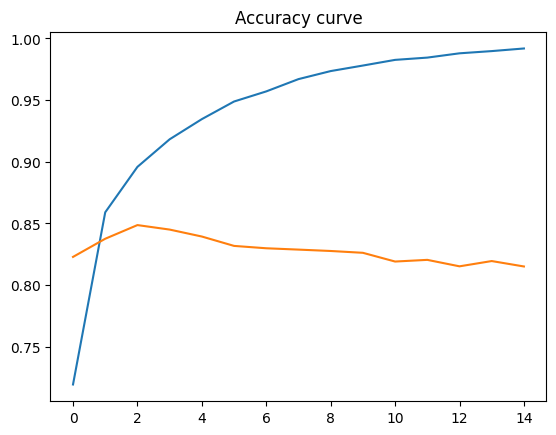

In [45]:
plt.plot(history3.history['accuracy'], label='Train')
plt.plot(history3.history['val_accuracy'], label='Val')
plt.title("Accuracy curve")
plt.show()

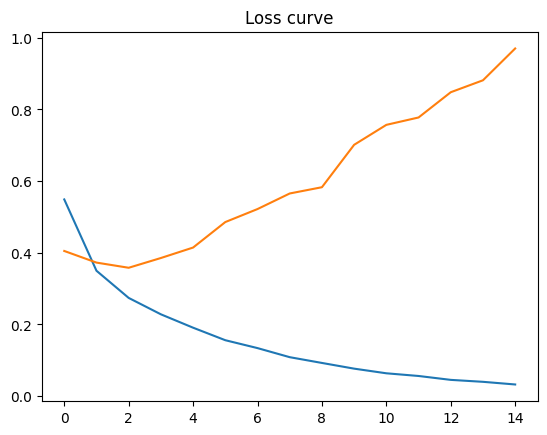

In [46]:
plt.plot(history3.history['loss'], label='Train')
plt.plot(history3.history['val_loss'], label='Val')
plt.title("Loss curve")
plt.show()